# Deliverable 2: Dataset Notebook  
## Skew-Aware Federated Learning for Client-Level Lesion Imbalance in Medical Image Segmentation

**Group Members:** Zainab Usman (27100409), Muhammad Sameel Haider (27100045)




## Why FeTS2022 fits our project
FeTS2022 is the best main choice for our project because it already gives a **federated** brain tumor segmentation setting with **multiple institutional clients**. This matches our research direction very well, because we want to study of hospital-level lesion-size skew


It is also useful because lesion size can be measured directly from the segmentation masks. That allows us to divide cases into **small**, **medium**, and **large** lesion groups in a controlled way.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
from google.colab import drive
import pandas as pd

## 1. Mount Drive and set dataset paths
The data has already been unzipped in Google Drive


In [5]:

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:


TRAIN_PARENT = Path('/content/drive/MyDrive/FeTS_unzipped/train')
TEST_PARENT  = Path('/content/drive/MyDrive/FeTS_unzipped/test')

TRAIN_ROOT = TRAIN_PARENT / 'MICCAI_FeTS2022_TrainingData'
TEST_ROOT  = TEST_PARENT / 'MICCAI_FeTS2022_ValidationData'

print("TRAIN_ROOT =", TRAIN_ROOT)
print("TEST_ROOT  =", TEST_ROOT)
print("Train path exists:", TRAIN_ROOT.exists())
print("Test path exists :", TEST_ROOT.exists())


TRAIN_ROOT = /content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData
TEST_ROOT  = /content/drive/MyDrive/FeTS_unzipped/test/MICCAI_FeTS2022_ValidationData
Train path exists: True
Test path exists : True


## 2. Count training and testing cases
This cell confirms the train/test split already provided in the dataset.


In [9]:
train_cases = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
test_cases  = sorted([p for p in TEST_ROOT.iterdir() if p.is_dir()])

print("Number of training cases:", len(train_cases))
print("Number of testing cases :", len(test_cases))
print("First 5 training cases:", [p.name for p in train_cases[:5]])
print("First 5 testing cases :", [p.name for p in test_cases[:5]])


Number of training cases: 1251
Number of testing cases : 219
First 5 training cases: ['FeTS2022_00000', 'FeTS2022_00002', 'FeTS2022_00003', 'FeTS2022_00005', 'FeTS2022_00006']
First 5 testing cases : ['FeTS2022_00001', 'FeTS2022_00013', 'FeTS2022_00015', 'FeTS2022_00027', 'FeTS2022_00037']


## 3. Inspect one case folder
This helps us verify the exact file naming for the MRI modalities and the segmentation mask.


In [10]:
sample_case = train_cases[0]
print("Sample training case folder:", sample_case)
print("\nFiles inside:")
for f in sorted(sample_case.iterdir()):
    print(" -", f.name)


Sample training case folder: /content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData/FeTS2022_00000

Files inside:
 - FeTS2022_00000_flair.nii.gz
 - FeTS2022_00000_seg.nii.gz
 - FeTS2022_00000_t1.nii.gz
 - FeTS2022_00000_t1ce.nii.gz
 - FeTS2022_00000_t2.nii.gz


## 4. Data format and annotations
FeTS2022 is a voxel-wise segmentation dataset.  
Each training case contains:

- 4 MRI modalities:
  - T1
  - T1Gd / T1CE
  - T2
  - FLAIR
- 1 segmentation mask

The mask gives tumor-related regions. For our project, the exact region identity is less important than the total lesion burden, because our partitioning will be based on **lesion size per case**.


In [11]:
def find_case_files(case_dir):
    files = list(case_dir.glob("*.nii.gz"))
    lower = {f.name.lower(): f for f in files}

    def find_one(options):
        for name, path in lower.items():
            for opt in options:
                if opt in name:
                    return path
        return None

    return {
        "t1": find_one(["_t1.nii", "t1.nii"]),
        "t1gd": find_one(["t1gd", "t1ce"]),
        "t2": find_one(["_t2.nii", "t2.nii"]),
        "flair": find_one(["flair"]),
        "mask": find_one(["seg", "mask", "label"])
    }

def load_nifti(path):
    return nib.load(str(path)).get_fdata()

def center_slice(vol):
    z = vol.shape[-1] // 2
    return vol[:, :, z]

def show_case(case_dir):
    paths = find_case_files(case_dir)

    vols = []
    titles = []

    for key, title in [("t1", "T1"), ("t1gd", "T1Gd"), ("t2", "T2"), ("flair", "FLAIR")]:
        if paths[key] is not None:
            vols.append(load_nifti(paths[key]))
            titles.append(title)

    mask = load_nifti(paths["mask"]) if paths["mask"] is not None else None

    ncols = len(vols) + (1 if mask is not None else 0)
    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))
    if ncols == 1:
        axes = [axes]

    for i, vol in enumerate(vols):
        axes[i].imshow(center_slice(vol).T, cmap="gray", origin="lower")
        axes[i].set_title(titles[i])
        axes[i].axis("off")

    if mask is not None:
        axes[-1].imshow(center_slice(mask).T, cmap="gray", origin="lower")
        axes[-1].set_title("Mask")
        axes[-1].axis("off")

    fig.suptitle(case_dir.name)
    plt.tight_layout()
    plt.show()


## 5. Show sample images and annotations
A few real training cases are displayed:


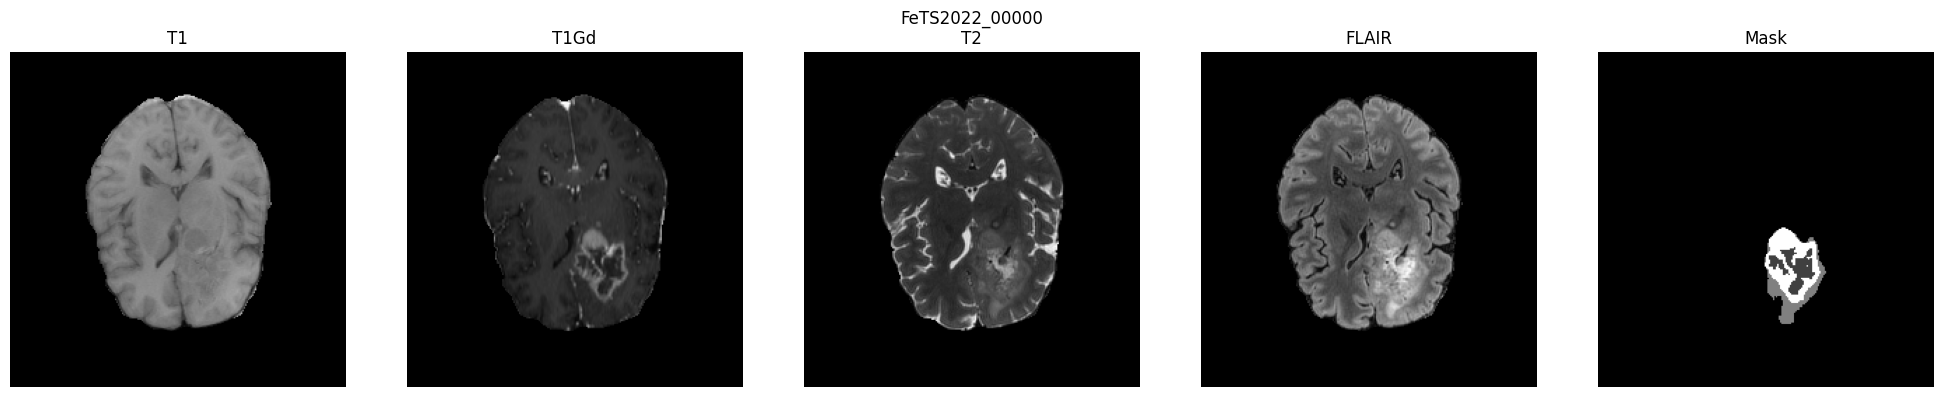

In [12]:
show_case(train_cases[0])


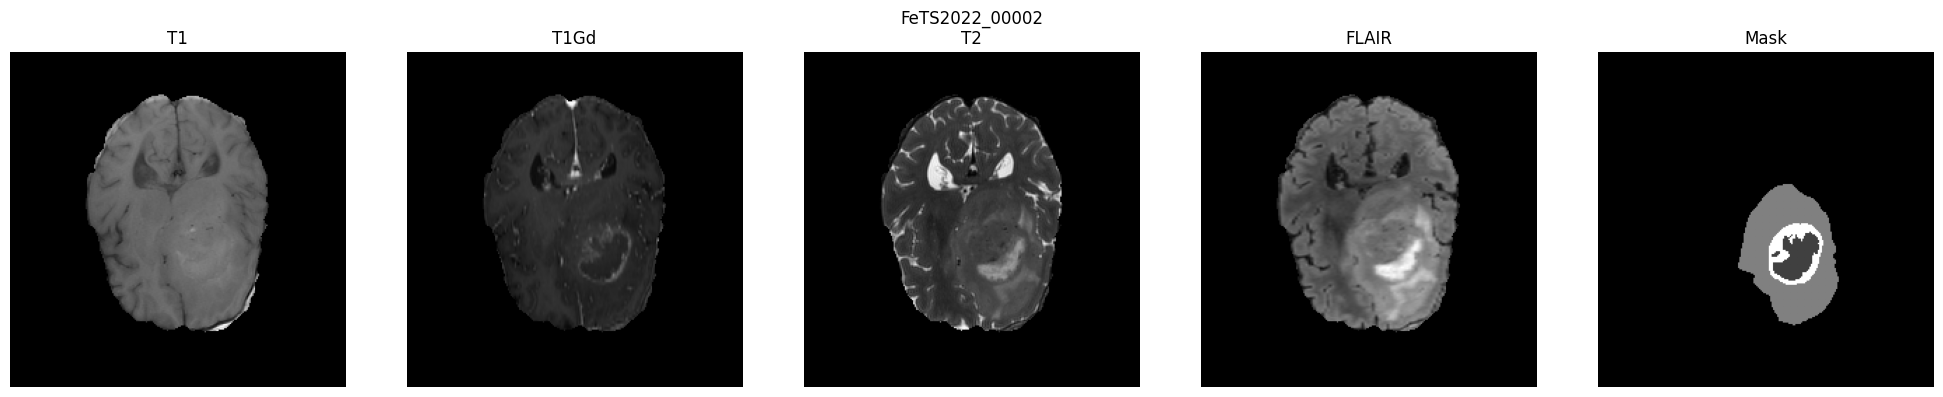

In [13]:
show_case(train_cases[1])


## 6. Check annotation label values
This helps us understand the label structure in the segmentation masks.

We will verify the labels on a small number of cases instead of scanning the whole training set.


In [14]:
def get_mask_labels_fast(case_dir):
    paths = find_case_files(case_dir)
    if paths["mask"] is None:
        return None
    img = nib.load(str(paths["mask"]))
    mask = np.asanyarray(img.dataobj)
    return np.unique(mask)

all_labels = set()

for case_dir in train_cases[:10]:
    labels = get_mask_labels_fast(case_dir)
    if labels is not None:
        all_labels.update(labels.tolist())
    print(case_dir.name, sorted(all_labels))

print("\nAll unique labels found in checked cases:", sorted(all_labels))
print("Number of unique labels:", len(all_labels))


FeTS2022_00000 [0, 1, 2, 4]
FeTS2022_00002 [0, 1, 2, 4]
FeTS2022_00003 [0, 1, 2, 4]
FeTS2022_00005 [0, 1, 2, 4]
FeTS2022_00006 [0, 1, 2, 4]
FeTS2022_00008 [0, 1, 2, 4]
FeTS2022_00009 [0, 1, 2, 4]
FeTS2022_00011 [0, 1, 2, 4]
FeTS2022_00012 [0, 1, 2, 4]
FeTS2022_00014 [0, 1, 2, 4]

All unique labels found in checked cases: [0, 1, 2, 4]
Number of unique labels: 4


### Note on labels
The checked masks use the label values **0, 1, 2, and 4**. The value **0** is the background, and the non-zero values correspond to tumor regions. Since our project focuses on lesion imbalance rather than subregion-specific classification, we will treat all non-zero labels as tumor foreground when measuring lesion size.

## 7. Compute lesion volume for each training case
This is the most important dataset-specific step for our revised project.  
We use the segmentation mask to compute **total lesion volume** for each case.


In [15]:
def lesion_volume(case_dir):
    paths = find_case_files(case_dir)
    if paths["mask"] is None:
        return None
    mask = load_nifti(paths["mask"])
    return int((mask > 0).sum())



lesion_stats = []
for case_dir in train_cases:
    vol = lesion_volume(case_dir)
    lesion_stats.append({
        "case": case_dir.name,
        "lesion_volume": vol
    })

lesion_df = pd.DataFrame(lesion_stats)
lesion_df.head()


,case,lesion_volume
0,FeTS2022_00000,57305
1,FeTS2022_00002,190594
2,FeTS2022_00003,99239
3,FeTS2022_00005,124783
4,FeTS2022_00006,137911


## 8. Plot the lesion-size distribution



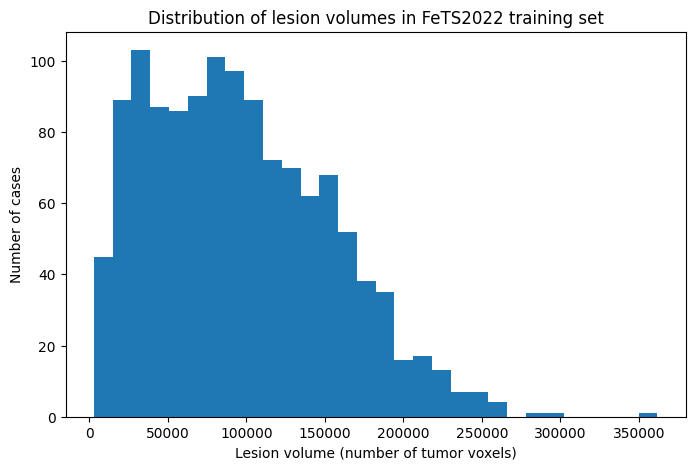

In [21]:
plt.figure(figsize=(8,5))
plt.hist(lesion_df["lesion_volume"], bins=30)
plt.title("Distribution of lesion volumes in FeTS2022 training set")
plt.xlabel("Lesion volume (number of tumor voxels)")
plt.ylabel("Number of cases")
plt.show()


## 9. Create case-level lesion-size groups
To build lesion-imbalanced clients later, we first convert each case into a simple size category:
- small
- medium
- large

These are not segmentation labels.  
They are **case-level pseudo-labels** used only for client partitioning.


In [17]:
q1 = lesion_df["lesion_volume"].quantile(0.33)
q2 = lesion_df["lesion_volume"].quantile(0.66)

def assign_group(v):
    if v <= q1:
        return "small"
    elif v <= q2:
        return "medium"
    else:
        return "large"

lesion_df["size_group"] = lesion_df["lesion_volume"].apply(assign_group)

print("Lower threshold:", q1)
print("Upper threshold:", q2)
print()
print(lesion_df["size_group"].value_counts())


Lower threshold: 63001.0
Upper threshold: 117131.0

size_group
large     425
small     413
medium    413
Name: count, dtype: int64


In [18]:
summary_table = lesion_df.groupby("size_group")["lesion_volume"].agg(["count", "min", "median", "max"])
summary_table


,count,min,median,max
size_group,,,,
large,425,117203,154118.0,361783
medium,413,63061,88373.0,117131
small,413,2808,34854.0,62941


## 10. One small-lesion case and one large-lesion case



Small lesion case: FeTS2022_00000


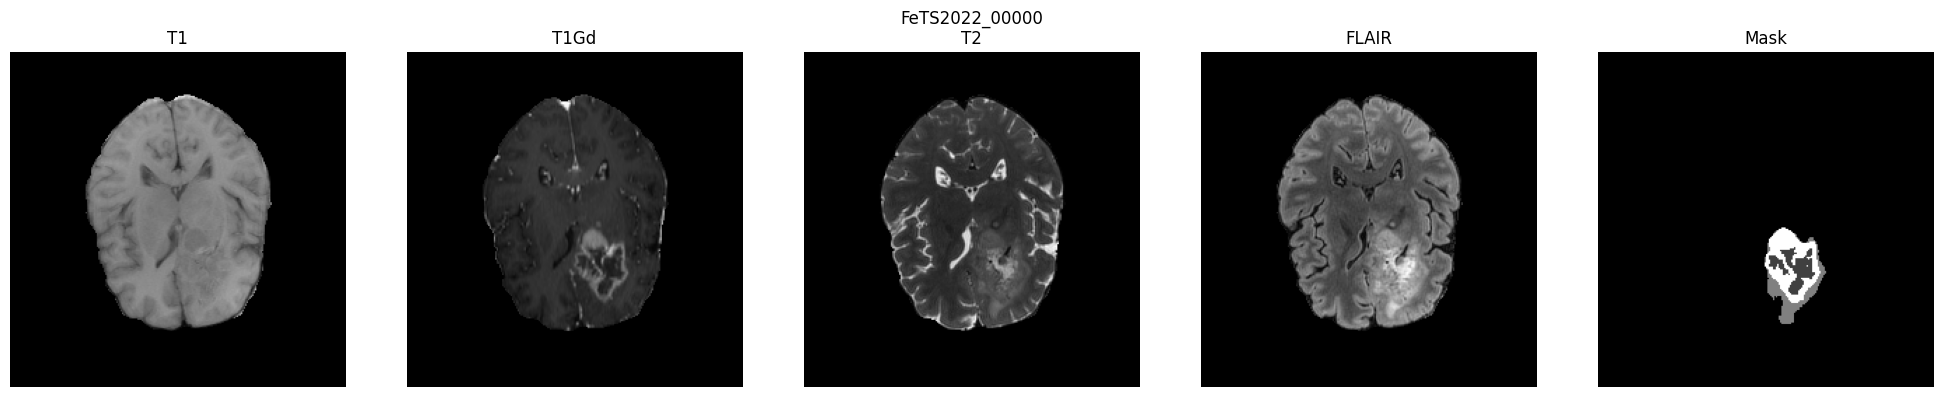

Large lesion case: FeTS2022_00002


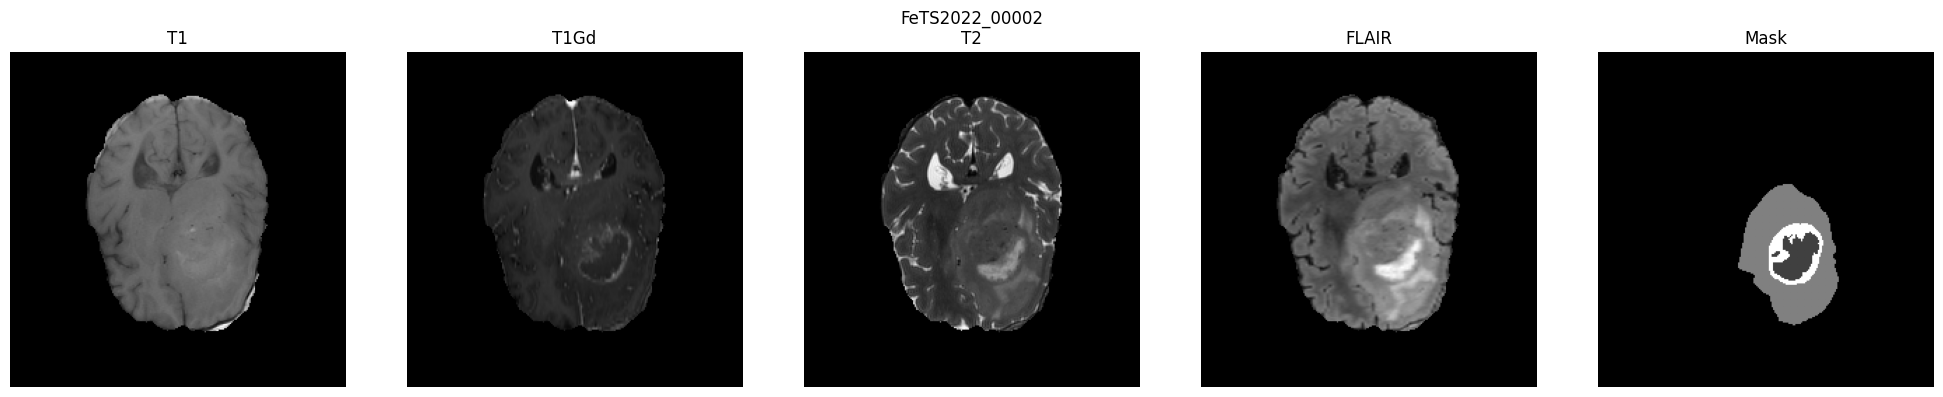

In [19]:
small_case_name = lesion_df[lesion_df["size_group"] == "small"].iloc[0]["case"]
large_case_name = lesion_df[lesion_df["size_group"] == "large"].iloc[0]["case"]

small_case_dir = TRAIN_ROOT / small_case_name
large_case_dir = TRAIN_ROOT / large_case_name

print("Small lesion case:", small_case_name)
show_case(small_case_dir)

print("Large lesion case:", large_case_name)
show_case(large_case_dir)


## 11. Official split and later experimental use
The dataset is already provided in separate **training** and **testing** folders.

For our project:
- lesion-size analysis is done on the training set
- the testing set stays separate
- if needed later, the training set can be split again into train / validation subsets at **patient level**

This is important to avoid leakage.


## 12. How we will use this dataset for the project
The TAs advised us to focus only on **lesion imbalance** and keep client quantity fixed.  
So the next step is **not** to use the original client sizes directly as the main variable.

Instead, our plan is:

- choose a fixed number of clients
- give each client the **same number of cases**
- change only the **lesion-size composition** of the clients

This way, if one client performs poorly, we can say the difference is coming mainly from lesion imbalance, not from data quantity.


In [20]:

# note: this is only a planning table for the project direction.

planned_clients = pd.DataFrame({
    "client": ["Client_1", "Client_2", "Client_3", "Client_4", "Client_5"],
    "cases_per_client": [100, 100, 100, 100, 100],
    "intended_lesion_profile": [
        "small-heavy",
        "small-medium",
        "balanced",
        "medium-large",
        "large-heavy"
    ]
})
planned_clients


,client,cases_per_client,intended_lesion_profile
0,Client_1,100,small-heavy
1,Client_2,100,small-medium
2,Client_3,100,balanced
3,Client_4,100,medium-large
4,Client_5,100,large-heavy


## 13. Planned partition logic
There are two possible ways to create lesion-imbalanced clients later:

### Option 1: Manual controlled partition
We manually assign equal numbers of cases to each client while controlling the ratio of small / medium / large lesion cases.

### Option 2: Dirichlet partitioning over lesion-size groups
We first treat the lesion-size groups as case-level pseudo-labels, then use Dirichlet partitioning to create non-IID client distributions while keeping client size fixed or nearly fixed.

At this stage, both ideas are being considered, but the main point is the same: **client quantity should stay controlled, and only lesion distribution should vary.**


## 15. Baseline implementation
Based on this dataset study, the next project stepd we aim for are:

- keep a standard segmentation backbone
- create equal-sized but lesion-skewed clients
- compare standard FL baselines such as local training, FedAvg, FedProx, and possibly SCAFFOLD / FedBN
- then test whether a lesion-aware method improves worst-client and small-lesion performance

